# Part 1: A minimal lineage-damage model with death

This notebook contains only four processes: fixed damage accumulation, fixed repair, asymmetric partitioning, and threshold-based death. It intentionally does **not** include damage feedback (`f`) or repair decline (`q`).

## Model rule

$$P_t = \max(0, (1-r)D_t + a + \epsilon_t)$$

$$P_t \ge T \Rightarrow \text{cell dies before division}$$

$$D^O_{t+1}=(0.5+s)P_t, \qquad D^N_{t+1}=(0.5-s)P_t$$

D_t is parent damage at the start of the cycle; a is new damage; r is the repaired fraction; epsilon_t is cycle-to-cycle noise; T is the death threshold; and s is partitioning asymmetry. If the parent survives, O receives the larger damage share and N the smaller share.

In [1]:
from dataclasses import dataclass
from random import Random
import matplotlib.pyplot as plt

@dataclass
class Cell:
    cell_id: int
    parent_id: int | None
    generation: int
    damage: float
    branch: str
    old_count: int
    alive: bool = True

def update_damage(damage, damage_per_cycle, repair, noise_sd, rng):
    return max(0.0, (1 - repair) * damage + damage_per_cycle + rng.gauss(0, noise_sd))

def simulate_lineage(generations=8, damage_per_cycle=1.0, repair=0.12,
                     asymmetry=0.18, noise_sd=0.12, death_threshold=2.5, seed=7):
    rng = Random(seed)
    cells = [Cell(0, None, 0, 0.0, '', 0)]
    current, next_id = [cells[0]], 1
    for generation in range(1, generations + 1):
        next_generation = []
        for parent in current:
            before_division = update_damage(parent.damage, damage_per_cycle, repair, noise_sd, rng)
            if before_division >= death_threshold:
                parent.damage, parent.alive = before_division, False
                continue
            old = Cell(next_id, parent.cell_id, generation, (0.5 + asymmetry) * before_division, parent.branch + 'O', parent.old_count + 1)
            new = Cell(next_id + 1, parent.cell_id, generation, (0.5 - asymmetry) * before_division, parent.branch + 'N', parent.old_count)
            cells.extend((old, new))
            next_generation.extend((old, new))
            next_id += 2
        current = next_generation
        if not current:
            break
    return cells

def plot_lineage_dashboard(cells, generations):
    children = {cell.cell_id: [] for cell in cells}
    for cell in cells:
        if cell.parent_id is not None:
            children[cell.parent_id].append(cell.cell_id)
    leaves = [cell for cell in cells if not children[cell.cell_id]]
    positions = {cell.cell_id: (i, cell.generation) for i, cell in enumerate(leaves)}
    for generation in range(generations - 1, -1, -1):
        for cell in [c for c in cells if c.generation == generation and children[c.cell_id]]:
            xs = [positions[child_id][0] for child_id in children[cell.cell_id]]
            positions[cell.cell_id] = (sum(xs) / len(xs), cell.generation)

    terminal = [cell for cell in cells if cell.cell_id in {leaf.cell_id for leaf in leaves}]
    survivors = [cell for cell in terminal if cell.alive and cell.generation == generations]
    deaths = [cell for cell in cells if not cell.alive]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for cell in cells:
        if cell.parent_id is not None:
            x0, y0 = positions[cell.parent_id]
            x1, y1 = positions[cell.cell_id]
            color = '#b64e3b' if cell.branch.endswith('O') else '#4d7496'
            axes[0].plot([x0, x1], [y0, y1], color=color, alpha=.38, lw=.75)
    nodes = axes[0].scatter(*zip(*[positions[cell.cell_id] for cell in cells]), c=[cell.damage for cell in cells], cmap='plasma', s=22, zorder=3)
    for cell in deaths:
        axes[0].plot(*positions[cell.cell_id], marker='x', color='black', ms=7, mew=1.5, zorder=4)
    axes[0].invert_yaxis()
    axes[0].set(title='Lineage tree', xlabel='terminal order', ylabel='generation')
    fig.colorbar(nodes, ax=axes[0], label='damage', pad=.01)

    if survivors:
        axes[1].hist([cell.damage for cell in survivors], bins=12, color='#735b9a', edgecolor='white')
    else:
        axes[1].text(.5, .5, 'No terminal survivors', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set(title='Terminal damage distribution', xlabel='damage', ylabel='terminal cells')

    if len(survivors) >= 2:
        xs = [cell.old_count for cell in survivors]
        ys = [cell.damage for cell in survivors]
        axes[2].scatter(xs, ys, color='#243b53', alpha=.72)
        mean_x, mean_y = sum(xs) / len(xs), sum(ys) / len(ys)
        numerator = sum((x - mean_x) * (y - mean_y) for x, y in zip(xs, ys))
        x_spread = sum((x - mean_x) ** 2 for x in xs)
        y_spread = sum((y - mean_y) ** 2 for y in ys)
        correlation = numerator / max((x_spread * y_spread) ** .5, 1e-12)
        if x_spread > 0:
            slope, intercept = numerator / x_spread, mean_y - numerator / x_spread * mean_x
            x_line = [min(xs), max(xs)]
            axes[2].plot(x_line, [slope * x + intercept for x in x_line], color='#d95f02', lw=2)
        title = f'Inheritance signal (r={correlation:.2f})'
    else:
        axes[2].text(.5, .5, 'Too few terminal survivors', ha='center', va='center', transform=axes[2].transAxes)
        title = 'Inheritance signal'
    axes[2].set(title=title, xlabel='number of O decisions', ylabel='terminal damage')
    plt.tight_layout()
    return None

Terminal cells at generation 8: 246
Cells that died before dividing: 2
Mean terminal damage: 0.89


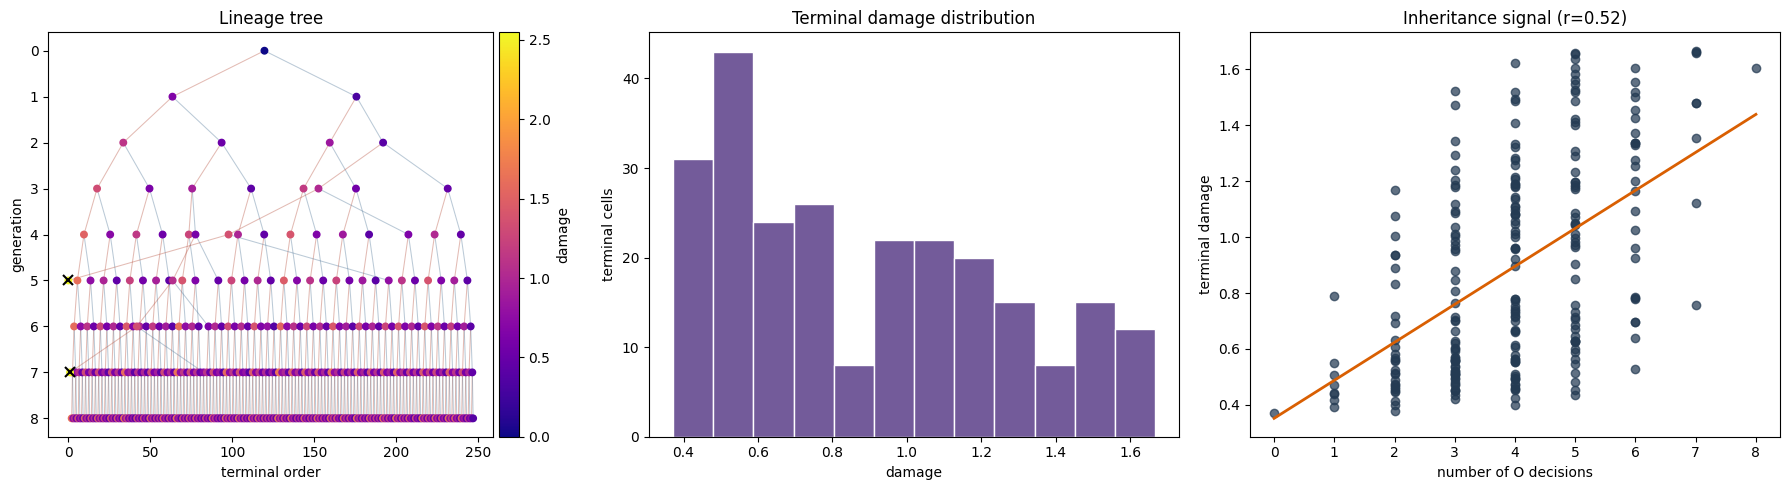

In [2]:
# Change these six values, then run this cell. It prints the summary and displays the three-panel dashboard.
params = dict(generations=8, damage_per_cycle=1.0, repair=0.12, asymmetry=0.18,
              noise_sd=0.12, death_threshold=2.5, seed=7)
cells = simulate_lineage(**params)

parent_ids = {cell.parent_id for cell in cells if cell.parent_id is not None}
terminal = [cell for cell in cells if cell.cell_id not in parent_ids]
survivors = [cell for cell in terminal if cell.alive and cell.generation == params['generations']]
deaths = [cell for cell in cells if not cell.alive]
print(f'Terminal cells at generation {params["generations"]}: {len(survivors)}')
print(f'Cells that died before dividing: {len(deaths)}')
print(f'Mean terminal damage: {sum(c.damage for c in survivors) / len(survivors):.2f}' if survivors else 'No terminal survivors')
plot_lineage_dashboard(cells, params['generations'])

In [3]:
# Change params above and rerun that cell to refresh lineage, terminal damage distribution, and inheritance signal.

## Explore

1. Set `asymmetry=0`. Does O-history still systematically predict terminal damage?
2. Lower `death_threshold` while holding all other parameters fixed. Which lineages vanish first?
3. Raise `repair`. Does it alter partitioning, or does it alter whether a lineage reaches the risky division?
4. Edit `update_damage` to test one biological hypothesis, and state what extra measurement would distinguish it from a noise-only explanation.